In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq8.Ser8.Img13.dcm
/kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq3.Ser3.Img11.jpg
/kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq21.Ser21.Img17.dcm
/kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq6.Ser6.Img6.jpg
/kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq3.Ser3.Img28.jpg
/kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq13.Ser13.Img10.jpg
/kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq22.Ser22.Img46.dcm
/kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq27.Ser27.Img1.jpg
/kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq15.Ser15.Img45.dcm
/kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq19.Ser19.Img32.dcm
/kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq22.Ser22.Img42.dcm
/kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq26.Ser26.Img44.jpg
/k

Loading all slices...


  3%|▎         | 45/1598 [00:00<00:03, 442.22it/s]


DICOM File: /kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq1.Ser1.Img1.dcm
Patient Name: ADC PHANTOM^ TEST
Patient ID: 2025.03.11-08:52:28-DST-1.3.12.2.1107.5.99.3
Study Date: 20250311
Modality: MR
Image Shape: (256, 256)

DICOM File: /kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq1.Ser1.Img10.dcm
Patient Name: ADC PHANTOM^ TEST
Patient ID: 2025.03.11-08:52:28-DST-1.3.12.2.1107.5.99.3
Study Date: 20250311
Modality: MR
Image Shape: (256, 256)

DICOM File: /kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq1.Ser1.Img11.dcm
Patient Name: ADC PHANTOM^ TEST
Patient ID: 2025.03.11-08:52:28-DST-1.3.12.2.1107.5.99.3
Study Date: 20250311
Modality: MR
Image Shape: (256, 256)


100%|██████████| 1598/1598 [00:03<00:00, 460.31it/s]


Total slices loaded: (1598, 128, 128)
Using 13 classes (background + tubes)
Epoch 1/10, Train Loss: 0.7317, Test Loss: 0.6288
Epoch 2/10, Train Loss: 0.5910, Test Loss: 0.5396
Epoch 3/10, Train Loss: 0.5214, Test Loss: 0.5196
Epoch 4/10, Train Loss: 0.4480, Test Loss: 0.3809
Epoch 5/10, Train Loss: 0.4094, Test Loss: 0.4209
Epoch 6/10, Train Loss: 0.3794, Test Loss: 0.3512
Epoch 7/10, Train Loss: 0.3433, Test Loss: 0.3742
Epoch 8/10, Train Loss: 0.3654, Test Loss: 0.3578
Epoch 9/10, Train Loss: 0.3436, Test Loss: 0.3723
Epoch 10/10, Train Loss: 0.3437, Test Loss: 0.3191


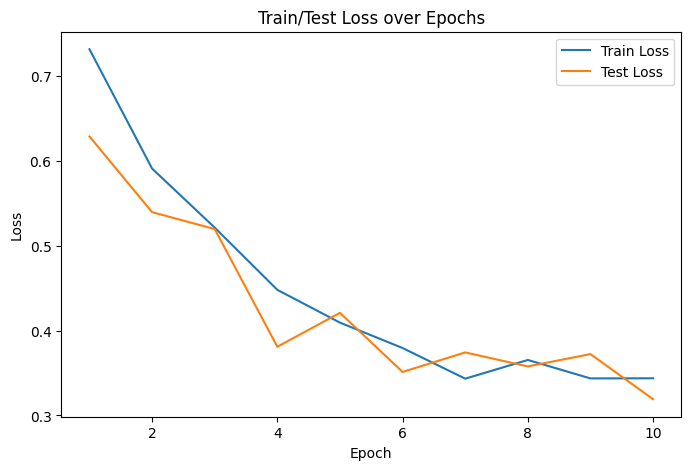

Train intensity stats saved to train_tube_intensity_stats.csv
Test intensity stats saved to test_tube_intensity_stats.csv
Image 0 region stats: {1: {'mean': -0.07798700034618378, 'std': 0.7465426921844482, 'count': 120}, 2: {'mean': 0.3292306661605835, 'std': 0.44819337129592896, 'count': 21971}}
Image 1 region stats: {1: {'mean': -0.061067190021276474, 'std': 0.7419984936714172, 'count': 120}, 2: {'mean': 0.33914610743522644, 'std': 0.4450864791870117, 'count': 21944}}
Image 2 region stats: {1: {'mean': 0.529319167137146, 'std': 0.7131446599960327, 'count': 739}, 2: {'mean': 0.5499516725540161, 'std': 0.8974752426147461, 'count': 764}, 3: {'mean': 0.1143769696354866, 'std': 0.8611655831336975, 'count': 773}, 4: {'mean': 0.4170380234718323, 'std': 0.562127411365509, 'count': 679}, 5: {'mean': -0.18250523507595062, 'std': 0.6861626505851746, 'count': 810}, 6: {'mean': -0.12338688224554062, 'std': 0.3799405097961426, 'count': 653}, 7: {'mean': 0.04234880581498146, 'std': 0.61809617280960

/tmp/ipykernel_182/1912023515.py:233: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', num_classes)


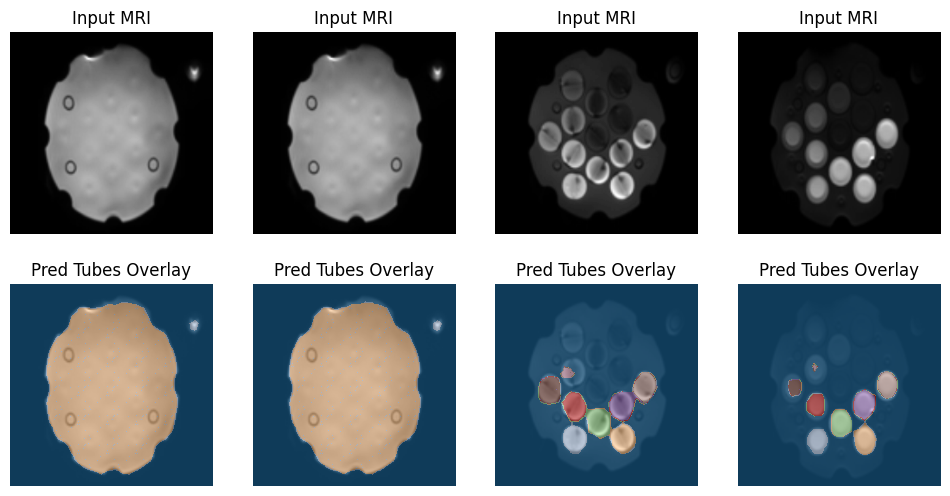

In [20]:
# ============================================================
# Complete MRI Phantom Segmentation Pipeline (All Slices)
# ============================================================

import os, glob
import numpy as np
import pydicom
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models.segmentation as seg_models
import matplotlib.colors as mcolors

from sklearn.model_selection import train_test_split

# ============================================================
# 1. Load all DICOM slices
# ============================================================
data_dir = "/kaggle/input/adc-phantom/ADC PHANTOM, TEST/"
dicom_files = sorted(glob.glob(os.path.join(data_dir, "*.dcm")))

target_size = (128, 128)
all_slices = []

print("Loading all slices...")
for idx, f in enumerate(tqdm(dicom_files)):
    ds = pydicom.dcmread(f)
    if idx < 3:
        print(f"\nDICOM File: {f}")
        print("Patient Name:", ds.get("PatientName", "N/A"))
        print("Patient ID:", ds.get("PatientID", "N/A"))
        print("Study Date:", ds.get("StudyDate", "N/A"))
        print("Modality:", ds.get("Modality", "N/A"))
        print("Image Shape:", ds.pixel_array.shape)
    img = ds.pixel_array.astype(np.float32)
    img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    all_slices.append(img_resized)

stack = np.stack(all_slices, axis=0)
print("Total slices loaded:", stack.shape)  # e.g., (1598, 128, 128)

# ============================================================
# 2. Multi-class mask generation
# ============================================================
def generate_multiclass_mask(img, max_classes=12):
    img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, mask = cv2.threshold(img_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    num_tubes = min(len(contours), max_classes)
    multiclass_mask = np.zeros_like(mask, dtype=np.uint8)
    
    for i, cnt in enumerate(contours[:num_tubes]):
        cv2.drawContours(multiclass_mask, [cnt], -1, i+1, -1)
    
    return multiclass_mask, num_tubes

# ============================================================
# 3. PyTorch Dataset
# ============================================================
class PhantomMRIDatasetOriginal(Dataset):
    def __init__(self, image_stack, transform=None, mask_size=(224,224), max_classes=12):
        self.images = []
        self.masks = []
        self.transform = transform
        self.mask_size = mask_size
        self.max_classes = max_classes
        self.detected_classes = 0
        
        for img in image_stack:
            mask, n_tubes = generate_multiclass_mask(img, max_classes=self.max_classes)
            self.detected_classes = max(self.detected_classes, n_tubes)
            
            mask_resized = cv2.resize(mask, self.mask_size, interpolation=cv2.INTER_NEAREST)
            
            img_norm = img.astype(np.float32)
            img_norm -= img_norm.min()
            img_norm /= (img_norm.max() + 1e-6)
            img_norm = (img_norm * 255).astype(np.uint8)
            
            self.images.append(img_norm)
            self.masks.append(mask_resized.astype(np.uint8))
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = self.images[idx]
        mask = self.masks[idx]
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        if self.transform:
            img = self.transform(img)
        mask = torch.tensor(mask, dtype=torch.long)
        return img, mask

# ============================================================
# 4. Transform (with normalization)
# ============================================================
transform_original = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# ============================================================
# 5. Train/test split
# ============================================================
train_imgs, test_imgs = train_test_split(stack, test_size=0.2, random_state=42)

train_dataset = PhantomMRIDatasetOriginal(train_imgs, transform=transform_original, max_classes=12)
test_dataset = PhantomMRIDatasetOriginal(test_imgs, transform=transform_original, max_classes=12)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

num_classes = max(train_dataset.detected_classes, test_dataset.detected_classes) + 1
print(f"Using {num_classes} classes (background + tubes)")

# ============================================================
# 6. Model setup with GroupNorm
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained DeepLabV3
model = seg_models.deeplabv3_resnet50(weights=seg_models.DeepLabV3_ResNet50_Weights.DEFAULT)

# Replace BatchNorm with GroupNorm
def convert_bn_to_gn(module):
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            setattr(module, name, nn.GroupNorm(8, child.num_features))
        else:
            convert_bn_to_gn(child)

convert_bn_to_gn(model)
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
model = model.to(device)

# ============================================================
# 7. Training setup
# ============================================================
learning_rate = 1e-4
num_epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# ============================================================
# 8. Helper: Compute intensity stats
# ============================================================
def compute_region_stats(img, mask, num_classes):
    stats = {}
    for c in range(1, num_classes):
        region_pixels = img[mask == c]
        if len(region_pixels) > 0:
            stats[c] = {
                "mean": float(region_pixels.mean()),
                "std": float(region_pixels.std()),
                "count": int(len(region_pixels))
            }
    return stats

# ============================================================
# 9. Training loop with train/test loss
# ============================================================
train_losses, test_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)["out"]
        
        if outputs.shape[2:] != masks.shape[1:]:
            masks = torch.nn.functional.interpolate(
                masks.unsqueeze(1).float(),
                size=outputs.shape[2:],
                mode="nearest"
            ).squeeze(1).long()
        
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Test loss
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)["out"]
            if outputs.shape[2:] != masks.shape[1:]:
                masks = torch.nn.functional.interpolate(
                    masks.unsqueeze(1).float(),
                    size=outputs.shape[2:],
                    mode="nearest"
                ).squeeze(1).long()
            loss = criterion(outputs, masks)
            running_test_loss += loss.item()
    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

# ============================================================
# 10. Loss plot
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(range(1,num_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1,num_epochs+1), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Loss over Epochs")
plt.legend()
plt.show()

# ============================================================
# 11. Overlay visualization
# ============================================================
def show_predictions_overlay(imgs, preds, num_classes):
    cmap = plt.cm.get_cmap('tab20', num_classes)
    norm = mcolors.BoundaryNorm(boundaries=range(num_classes+1), ncolors=num_classes)

    plt.figure(figsize=(12,6))
    for i in range(min(len(imgs), 4)):
        img_np = imgs[i].permute(1,2,0).cpu().numpy()
        img_gray = np.mean(img_np, axis=2)
        pred_mask = preds[i]

        stats = compute_region_stats(img_gray, pred_mask, num_classes)
        print(f"Image {i} region stats:", stats)

        plt.subplot(2,4,i+1)
        plt.imshow(img_gray, cmap='gray')
        plt.title("Input MRI")
        plt.axis("off")

        plt.subplot(2,4,i+5)
        plt.imshow(img_gray, cmap='gray')
        plt.imshow(pred_mask, cmap=cmap, norm=norm, alpha=0.5)
        plt.title("Pred Tubes Overlay")
        plt.axis("off")
    plt.show()

# ============================================================
# 12. Extract intensity stats & save CSV
# ============================================================
def extract_intensity_stats(dataset_loader, dataset_type="train"):
    all_stats = []
    model.eval()
    with torch.no_grad():
        for idx, (imgs, masks) in enumerate(dataset_loader):
            imgs = imgs.to(device)
            outputs = model(imgs)["out"]
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            for b in range(len(imgs)):
                img_np = imgs[b].permute(1,2,0).cpu().numpy()
                img_gray = np.mean(img_np, axis=2)
                pred_mask = preds[b]
                
                stats = compute_region_stats(img_gray, pred_mask, num_classes)
                for tube_id, stat in stats.items():
                    all_stats.append({
                        "image_index": idx*dataset_loader.batch_size + b,
                        "dataset": dataset_type,
                        "tube_id": tube_id,
                        "mean_intensity": stat["mean"],
                        "std_intensity": stat["std"],
                        "pixel_count": stat["count"]
                    })
    return pd.DataFrame(all_stats)

# Train stats
train_stats_df = extract_intensity_stats(train_loader, "train")
train_stats_df.to_csv("train_tube_intensity_stats.csv", index=False)
print("Train intensity stats saved to train_tube_intensity_stats.csv")

# Test stats
test_stats_df = extract_intensity_stats(test_loader, "test")
test_stats_df.to_csv("test_tube_intensity_stats.csv", index=False)
print("Test intensity stats saved to test_tube_intensity_stats.csv")

# ============================================================
# 13. Visualize predictions for first batch
# ============================================================
with torch.no_grad():
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)["out"]
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        show_predictions_overlay(imgs.cpu(), preds, num_classes)
        break

Loading all slices...


  3%|▎         | 44/1598 [00:00<00:03, 439.82it/s]


DICOM File: /kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq1.Ser1.Img1.dcm
Patient Name: ADC PHANTOM^ TEST
Patient ID: 2025.03.11-08:52:28-DST-1.3.12.2.1107.5.99.3
Study Date: 20250311
Modality: MR
Image Shape: (256, 256)

DICOM File: /kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq1.Ser1.Img10.dcm
Patient Name: ADC PHANTOM^ TEST
Patient ID: 2025.03.11-08:52:28-DST-1.3.12.2.1107.5.99.3
Study Date: 20250311
Modality: MR
Image Shape: (256, 256)

DICOM File: /kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq1.Ser1.Img11.dcm
Patient Name: ADC PHANTOM^ TEST
Patient ID: 2025.03.11-08:52:28-DST-1.3.12.2.1107.5.99.3
Study Date: 20250311
Modality: MR
Image Shape: (256, 256)


100%|██████████| 1598/1598 [00:03<00:00, 445.76it/s]


Total slices loaded: (1598, 128, 128)
Using 13 classes (background + tubes)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Train: 0.8027, Val: 0.6493, Test: 0.6430
Epoch 2/50, Train: 0.6660, Val: 0.6158, Test: 0.6051
Epoch 3/50, Train: 0.6040, Val: 0.5346, Test: 0.5283
Epoch 4/50, Train: 0.5475, Val: 0.4947, Test: 0.4843
Epoch 5/50, Train: 0.5054, Val: 0.5017, Test: 0.4987
Epoch 6/50, Train: 0.5017, Val: 0.4873, Test: 0.4819
Epoch 7/50, Train: 0.4785, Val: 0.4504, Test: 0.4478
Epoch 8/50, Train: 0.4619, Val: 0.4354, Test: 0.4308
Epoch 9/50, Train: 0.4359, Val: 0.4431, Test: 0.4209
Epoch 10/50, Train: 0.4526, Val: 0.4119, Test: 0.4111
Epoch 11/50, Train: 0.4298, Val: 0.4239, Test: 0.4099
Epoch 12/50, Train: 0.4302, Val: 0.4172, Test: 0.4136
Epoch 13/50, Train: 0.4188, Val: 0.4046, Test: 0.4158
Epoch 14/50, Train: 0.4071, Val: 0.4300, Test: 0.4525
Epoch 15/50, Train: 0.3946, Val: 0.4155, Test: 0.4285
Epoch 16/50, Train: 0.3975, Val: 0.3955, Test: 0.3958
Epoch 17/50, Train: 0.3801, Val: 0.3735, Test: 0.3791
Epoch 18/50, Train: 0.3780, Val: 0.3511, Test: 0.3636
Epoch 19/50, Train: 0.3537, Val: 0.36

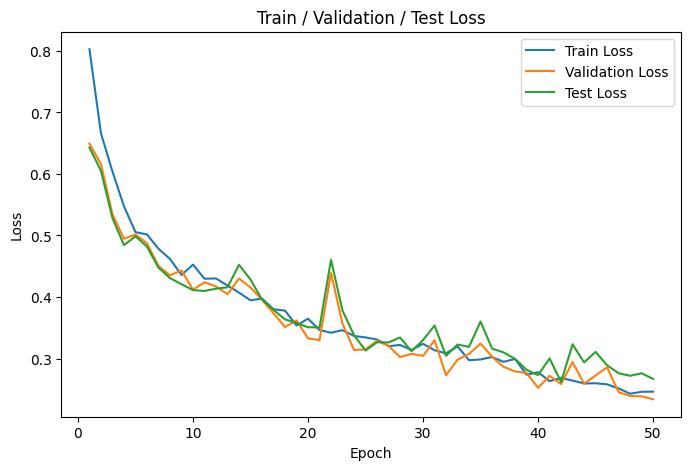

Intensity stats saved for train, val, test datasets.
Image 0 region stats: {1: {'mean': -0.6183383464813232, 'std': 1.2577193975448608, 'count': 549}, 2: {'mean': -0.9626568555831909, 'std': 0.9437047839164734, 'count': 623}, 3: {'mean': -0.0362357571721077, 'std': 1.0449298620224, 'count': 635}, 4: {'mean': 0.06602878123521805, 'std': 1.0083081722259521, 'count': 667}, 5: {'mean': -0.44164183735847473, 'std': 0.7809569239616394, 'count': 724}, 6: {'mean': -0.16896840929985046, 'std': 1.1486389636993408, 'count': 485}, 7: {'mean': -1.0423365831375122, 'std': 0.5434980988502502, 'count': 627}, 8: {'mean': -1.692803978919983, 'std': 0.025873901322484016, 'count': 261}}
Image 1 region stats: {}
Image 2 region stats: {7: {'mean': 0.4149457514286041, 'std': 0.478983610868454, 'count': 5505}, 8: {'mean': 0.40956059098243713, 'std': 0.5484769344329834, 'count': 3749}, 10: {'mean': 0.5857146978378296, 'std': 0.09706851094961166, 'count': 46}}
Image 3 region stats: {3: {'mean': -1.0121059417724

/tmp/ipykernel_182/384354966.py:281: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', num_classes)


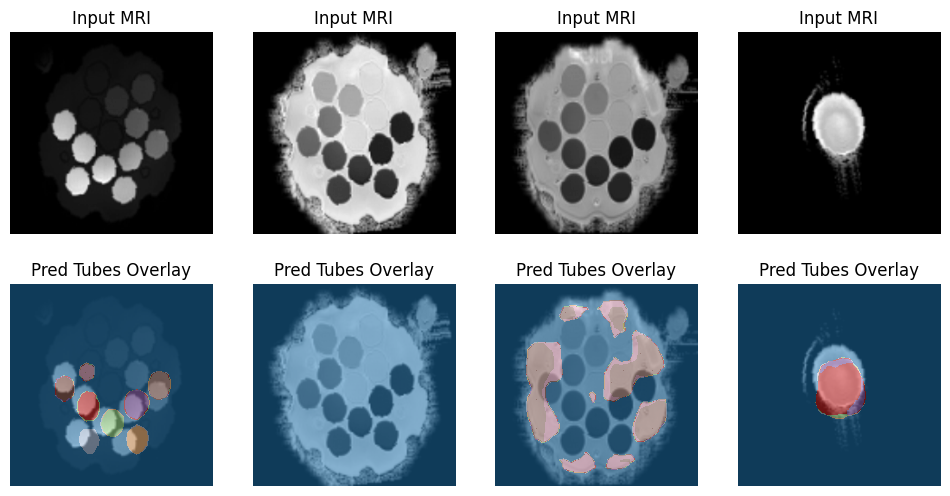

In [21]:
# ============================================================
# Complete MRI Phantom Segmentation Pipeline with Enhancements
# ============================================================

import os, glob
import numpy as np
import pydicom
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models.segmentation as seg_models
import matplotlib.colors as mcolors

from sklearn.model_selection import train_test_split

# ============================================================
# 1. Load all DICOM slices
# ============================================================
data_dir = "/kaggle/input/adc-phantom/ADC PHANTOM, TEST/"
dicom_files = sorted(glob.glob(os.path.join(data_dir, "*.dcm")))

target_size = (128, 128)
all_slices = []

print("Loading all slices...")
for idx, f in enumerate(tqdm(dicom_files)):
    ds = pydicom.dcmread(f)
    if idx < 3:
        print(f"\nDICOM File: {f}")
        print("Patient Name:", ds.get("PatientName", "N/A"))
        print("Patient ID:", ds.get("PatientID", "N/A"))
        print("Study Date:", ds.get("StudyDate", "N/A"))
        print("Modality:", ds.get("Modality", "N/A"))
        print("Image Shape:", ds.pixel_array.shape)
    img = ds.pixel_array.astype(np.float32)
    img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    all_slices.append(img_resized)

stack = np.stack(all_slices, axis=0)
print("Total slices loaded:", stack.shape)

# ============================================================
# 2. Multi-class mask generation
# ============================================================
def generate_multiclass_mask(img, max_classes=12):
    img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, mask = cv2.threshold(img_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    num_tubes = min(len(contours), max_classes)
    multiclass_mask = np.zeros_like(mask, dtype=np.uint8)
    
    for i, cnt in enumerate(contours[:num_tubes]):
        cv2.drawContours(multiclass_mask, [cnt], -1, i+1, -1)
    
    return multiclass_mask, num_tubes

# ============================================================
# 3. PyTorch Dataset
# ============================================================
class PhantomMRIDatasetOriginal(Dataset):
    def __init__(self, image_stack, transform=None, mask_size=(224,224), max_classes=12):
        self.images = []
        self.masks = []
        self.transform = transform
        self.mask_size = mask_size
        self.max_classes = max_classes
        self.detected_classes = 0
        
        for img in image_stack:
            mask, n_tubes = generate_multiclass_mask(img, max_classes=self.max_classes)
            self.detected_classes = max(self.detected_classes, n_tubes)
            
            mask_resized = cv2.resize(mask, self.mask_size, interpolation=cv2.INTER_NEAREST)
            
            img_norm = img.astype(np.float32)
            img_norm -= img_norm.min()
            img_norm /= (img_norm.max() + 1e-6)
            img_norm = (img_norm * 255).astype(np.uint8)
            
            self.images.append(img_norm)
            self.masks.append(mask_resized.astype(np.uint8))
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = self.images[idx]
        mask = self.masks[idx]
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        if self.transform:
            img = self.transform(img)
        mask = torch.tensor(mask, dtype=torch.long)
        return img, mask

# ============================================================
# 4. Data Augmentation + Normalization
# ============================================================
transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val_test = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# ============================================================
# 5. Train / Validation / Test Split
# ============================================================
train_val_imgs, test_imgs = train_test_split(stack, test_size=0.1, random_state=42)
train_imgs, val_imgs = train_test_split(train_val_imgs, test_size=0.1, random_state=42)

train_dataset = PhantomMRIDatasetOriginal(train_imgs, transform=transform_train, max_classes=12)
val_dataset = PhantomMRIDatasetOriginal(val_imgs, transform=transform_val_test, max_classes=12)
test_dataset = PhantomMRIDatasetOriginal(test_imgs, transform=transform_val_test, max_classes=12)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

num_classes = max(train_dataset.detected_classes, val_dataset.detected_classes, test_dataset.detected_classes) + 1
print(f"Using {num_classes} classes (background + tubes)")

# ============================================================
# 6. Model Setup with GroupNorm + Dropout
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = seg_models.deeplabv3_resnet50(weights=seg_models.DeepLabV3_ResNet50_Weights.DEFAULT)

def convert_bn_to_gn(module):
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            setattr(module, name, nn.GroupNorm(8, child.num_features))
        else:
            convert_bn_to_gn(child)
convert_bn_to_gn(model)

# Add Dropout in classifier
model.classifier[4] = nn.Sequential(
    nn.Conv2d(256, 256, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Dropout2d(0.3),
    nn.Conv2d(256, num_classes, kernel_size=1)
)
model = model.to(device)

# ============================================================
# 7. Training setup
# ============================================================
learning_rate = 1e-4
num_epochs = 50
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Early stopping
best_val_loss = np.inf
patience = 10
trigger_times = 0

# ============================================================
# 8. Helper: Compute intensity stats
# ============================================================
def compute_region_stats(img, mask, num_classes):
    stats = {}
    for c in range(1, num_classes):
        region_pixels = img[mask == c]
        if len(region_pixels) > 0:
            stats[c] = {
                "mean": float(region_pixels.mean()),
                "std": float(region_pixels.std()),
                "count": int(len(region_pixels))
            }
    return stats

# ============================================================
# 9. Training loop with early stopping
# ============================================================
train_losses, val_losses, test_losses = [], [], []

for epoch in range(num_epochs):
    # ----- Training -----
    model.train()
    running_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)["out"]
        if outputs.shape[2:] != masks.shape[1:]:
            masks = torch.nn.functional.interpolate(
                masks.unsqueeze(1).float(),
                size=outputs.shape[2:], mode="nearest"
            ).squeeze(1).long()
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ----- Validation -----
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)["out"]
            if outputs.shape[2:] != masks.shape[1:]:
                masks = torch.nn.functional.interpolate(
                    masks.unsqueeze(1).float(),
                    size=outputs.shape[2:], mode="nearest"
                ).squeeze(1).long()
            loss = criterion(outputs, masks)
            running_val_loss += loss.item()
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)

    # ----- Test -----
    running_test_loss = 0.0
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)["out"]
            if outputs.shape[2:] != masks.shape[1:]:
                masks = torch.nn.functional.interpolate(
                    masks.unsqueeze(1).float(),
                    size=outputs.shape[2:], mode="nearest"
                ).squeeze(1).long()
            loss = criterion(outputs, masks)
            running_test_loss += loss.item()
    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}, Test: {avg_test_loss:.4f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        trigger_times = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# ============================================================
# 10. Loss plot
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(range(1,len(train_losses)+1), train_losses, label="Train Loss")
plt.plot(range(1,len(val_losses)+1), val_losses, label="Validation Loss")
plt.plot(range(1,len(test_losses)+1), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Validation / Test Loss")
plt.legend()
plt.show()

# ============================================================
# 11. Overlay visualization
# ============================================================
def show_predictions_overlay(imgs, preds, num_classes):
    cmap = plt.cm.get_cmap('tab20', num_classes)
    norm = mcolors.BoundaryNorm(boundaries=range(num_classes+1), ncolors=num_classes)
    plt.figure(figsize=(12,6))
    for i in range(min(len(imgs), 4)):
        img_np = imgs[i].permute(1,2,0).cpu().numpy()
        img_gray = np.mean(img_np, axis=2)
        pred_mask = preds[i]
        stats = compute_region_stats(img_gray, pred_mask, num_classes)
        print(f"Image {i} region stats:", stats)
        plt.subplot(2,4,i+1)
        plt.imshow(img_gray, cmap='gray')
        plt.title("Input MRI")
        plt.axis("off")
        plt.subplot(2,4,i+5)
        plt.imshow(img_gray, cmap='gray')
        plt.imshow(pred_mask, cmap=cmap, norm=norm, alpha=0.5)
        plt.title("Pred Tubes Overlay")
        plt.axis("off")
    plt.show()

# ============================================================
# 12. Extract intensity stats & save CSV
# ============================================================
def extract_intensity_stats(dataset_loader, dataset_type="train"):
    all_stats = []
    model.eval()
    with torch.no_grad():
        for idx, (imgs, masks) in enumerate(dataset_loader):
            imgs = imgs.to(device)
            outputs = model(imgs)["out"]
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            for b in range(len(imgs)):
                img_np = imgs[b].permute(1,2,0).cpu().numpy()
                img_gray = np.mean(img_np, axis=2)
                pred_mask = preds[b]
                stats = compute_region_stats(img_gray, pred_mask, num_classes)
                for tube_id, stat in stats.items():
                    all_stats.append({
                        "image_index": idx*dataset_loader.batch_size + b,
                        "dataset": dataset_type,
                        "tube_id": tube_id,
                        "mean_intensity": stat["mean"],
                        "std_intensity": stat["std"],
                        "pixel_count": stat["count"]
                    })
    return pd.DataFrame(all_stats)

train_stats_df = extract_intensity_stats(train_loader, "train")
train_stats_df.to_csv("train_tube_intensity_stats.csv", index=False)
val_stats_df = extract_intensity_stats(val_loader, "val")
val_stats_df.to_csv("val_tube_intensity_stats.csv", index=False)
test_stats_df = extract_intensity_stats(test_loader, "test")
test_stats_df.to_csv("test_tube_intensity_stats.csv", index=False)
print("Intensity stats saved for train, val, test datasets.")

# ============================================================
# 13. Visualize first train batch predictions
# ============================================================
with torch.no_grad():
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)["out"]
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        show_predictions_overlay(imgs.cpu(), preds, num_classes)
        break


Loading all slices...


  2%|▏         | 30/1598 [00:00<00:05, 296.89it/s]


DICOM File: /kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq1.Ser1.Img1.dcm
Patient Name: ADC PHANTOM^ TEST
Patient ID: 2025.03.11-08:52:28-DST-1.3.12.2.1107.5.99.3
Study Date: 20250311
Modality: MR
Image Shape: (256, 256)

DICOM File: /kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq1.Ser1.Img10.dcm
Patient Name: ADC PHANTOM^ TEST
Patient ID: 2025.03.11-08:52:28-DST-1.3.12.2.1107.5.99.3
Study Date: 20250311
Modality: MR
Image Shape: (256, 256)

DICOM File: /kaggle/input/adc-phantom/ADC PHANTOM, TEST/ADC PHANTOM, TEST.Seq1.Ser1.Img11.dcm
Patient Name: ADC PHANTOM^ TEST
Patient ID: 2025.03.11-08:52:28-DST-1.3.12.2.1107.5.99.3
Study Date: 20250311
Modality: MR
Image Shape: (256, 256)


100%|██████████| 1598/1598 [00:05<00:00, 299.07it/s]


Total slices loaded: (1598, 128, 128)
Using 13 classes (background + tubes)
Epoch 1/50, Train: 0.8030, Val: 0.6596
Epoch 2/50, Train: 0.6846, Val: 0.6418
Epoch 3/50, Train: 0.6234, Val: 0.6151
Epoch 4/50, Train: 0.5793, Val: 0.5238
Epoch 5/50, Train: 0.5658, Val: 0.5160
Epoch 6/50, Train: 0.4955, Val: 0.4553
Epoch 7/50, Train: 0.4918, Val: 0.4614
Epoch 8/50, Train: 0.4668, Val: 0.4810
Epoch 9/50, Train: 0.4510, Val: 0.4307
Epoch 10/50, Train: 0.4400, Val: 0.4060
Epoch 11/50, Train: 0.4224, Val: 0.4041
Epoch 12/50, Train: 0.4237, Val: 0.4046
Epoch 13/50, Train: 0.4021, Val: 0.3712
Epoch 14/50, Train: 0.4054, Val: 0.4428
Epoch 15/50, Train: 0.4036, Val: 0.3736
Epoch 16/50, Train: 0.3912, Val: 0.3539
Epoch 17/50, Train: 0.3892, Val: 0.3684
Epoch 18/50, Train: 0.3748, Val: 0.3404
Epoch 19/50, Train: 0.3648, Val: 0.3591
Epoch 20/50, Train: 0.3561, Val: 0.3625
Epoch 21/50, Train: 0.3720, Val: 0.3823
Epoch 22/50, Train: 0.3466, Val: 0.3467
Epoch 23/50, Train: 0.3525, Val: 0.4185
Epoch 24/50, 

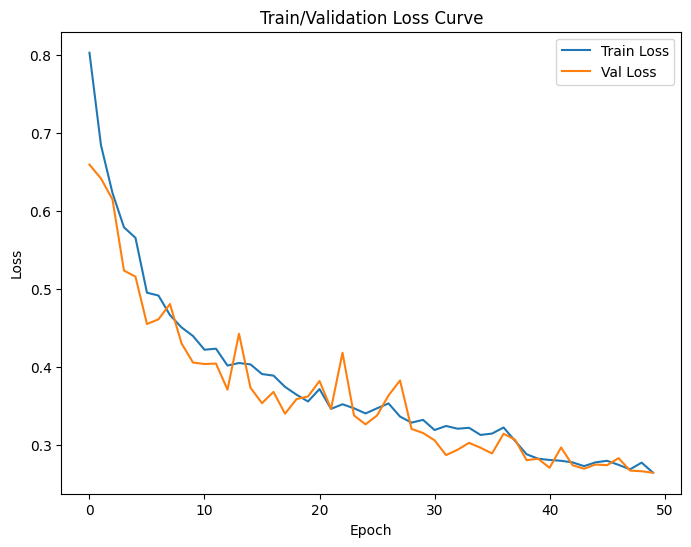

All segmentation metrics and intensity statistics saved.


/tmp/ipykernel_182/2922221877.py:346: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', num_classes)


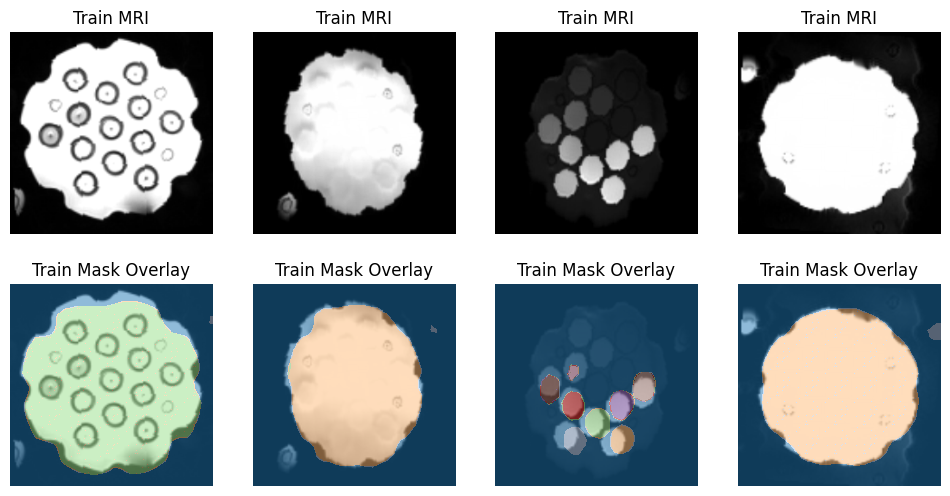

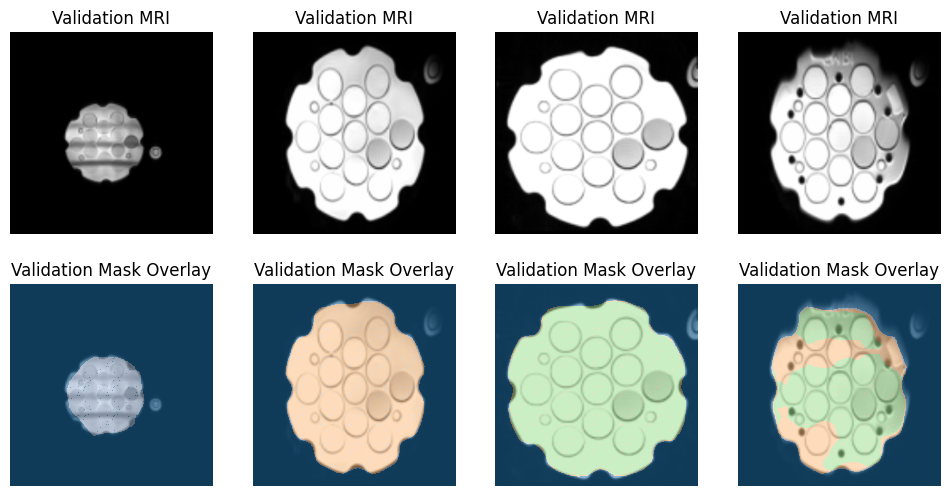

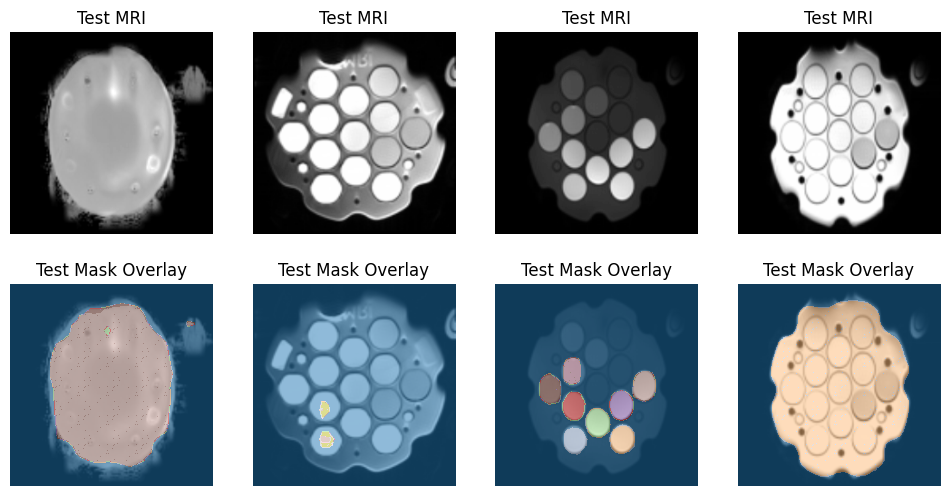

In [22]:
# ============================================================
# Complete MRI Phantom Segmentation Pipeline with Train/Val/Test
# ============================================================

import os, glob
import numpy as np
import pydicom
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models.segmentation as seg_models
import matplotlib.colors as mcolors

from sklearn.model_selection import train_test_split

# ============================================================
# 1. Load all DICOM slices
# ============================================================
data_dir = "/kaggle/input/adc-phantom/ADC PHANTOM, TEST/"
dicom_files = sorted(glob.glob(os.path.join(data_dir, "*.dcm")))

target_size = (128, 128)
all_slices = []

print("Loading all slices...")
for idx, f in enumerate(tqdm(dicom_files)):
    ds = pydicom.dcmread(f)
    if idx < 3:
        print(f"\nDICOM File: {f}")
        print("Patient Name:", ds.get("PatientName", "N/A"))
        print("Patient ID:", ds.get("PatientID", "N/A"))
        print("Study Date:", ds.get("StudyDate", "N/A"))
        print("Modality:", ds.get("Modality", "N/A"))
        print("Image Shape:", ds.pixel_array.shape)
    img = ds.pixel_array.astype(np.float32)
    img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    all_slices.append(img_resized)

stack = np.stack(all_slices, axis=0)
print("Total slices loaded:", stack.shape)

# ============================================================
# 2. Multi-class mask generation
# ============================================================
def generate_multiclass_mask(img, max_classes=12):
    img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, mask = cv2.threshold(img_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    num_tubes = min(len(contours), max_classes)
    multiclass_mask = np.zeros_like(mask, dtype=np.uint8)
    
    for i, cnt in enumerate(contours[:num_tubes]):
        cv2.drawContours(multiclass_mask, [cnt], -1, i+1, -1)
    
    return multiclass_mask, num_tubes

# ============================================================
# 3. PyTorch Dataset
# ============================================================
class PhantomMRIDatasetOriginal(Dataset):
    def __init__(self, image_stack, transform=None, mask_size=(224,224), max_classes=12):
        self.images = []
        self.masks = []
        self.transform = transform
        self.mask_size = mask_size
        self.max_classes = max_classes
        self.detected_classes = 0
        
        for img in image_stack:
            mask, n_tubes = generate_multiclass_mask(img, max_classes=self.max_classes)
            self.detected_classes = max(self.detected_classes, n_tubes)
            
            mask_resized = cv2.resize(mask, self.mask_size, interpolation=cv2.INTER_NEAREST)
            
            img_norm = img.astype(np.float32)
            img_norm -= img_norm.min()
            img_norm /= (img_norm.max() + 1e-6)
            img_norm = (img_norm * 255).astype(np.uint8)
            
            self.images.append(img_norm)
            self.masks.append(mask_resized.astype(np.uint8))
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = self.images[idx]
        mask = self.masks[idx]
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        if self.transform:
            img = self.transform(img)
        mask = torch.tensor(mask, dtype=torch.long)
        return img, mask

# ============================================================
# 4. Data Augmentation + Normalization
# ============================================================
transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val_test = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# ============================================================
# 5. Train / Validation / Test Split
# ============================================================
train_val_imgs, test_imgs = train_test_split(stack, test_size=0.1, random_state=42)
train_imgs, val_imgs = train_test_split(train_val_imgs, test_size=0.1, random_state=42)

train_dataset = PhantomMRIDatasetOriginal(train_imgs, transform=transform_train, max_classes=12)
val_dataset   = PhantomMRIDatasetOriginal(val_imgs, transform=transform_val_test, max_classes=12)
test_dataset  = PhantomMRIDatasetOriginal(test_imgs, transform=transform_val_test, max_classes=12)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

num_classes = max(train_dataset.detected_classes, val_dataset.detected_classes, test_dataset.detected_classes) + 1
print(f"Using {num_classes} classes (background + tubes)")

# ============================================================
# 6. Model Setup with GroupNorm + Dropout
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = seg_models.deeplabv3_resnet50(weights=seg_models.DeepLabV3_ResNet50_Weights.DEFAULT)

def convert_bn_to_gn(module):
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            setattr(module, name, nn.GroupNorm(8, child.num_features))
        else:
            convert_bn_to_gn(child)
convert_bn_to_gn(model)

model.classifier[4] = nn.Sequential(
    nn.Conv2d(256, 256, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Dropout2d(0.3),
    nn.Conv2d(256, num_classes, kernel_size=1)
)
model = model.to(device)

# ============================================================
# 7. Training setup
# ============================================================
learning_rate = 1e-4
num_epochs = 50
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

best_val_loss = np.inf
patience = 10
trigger_times = 0

# ============================================================
# 8. Metrics
# ============================================================
def dice_coefficient(pred, target, num_classes):
    dices = []
    pred = pred.flatten()
    target = target.flatten()
    for c in range(1, num_classes):
        pred_c = (pred == c).float()
        target_c = (target == c).float()
        inter = (pred_c * target_c).sum()
        dice = (2. * inter) / (pred_c.sum() + target_c.sum() + 1e-6)
        dices.append(dice.item())
    return dices

def iou_score(pred, target, num_classes):
    ious = []
    pred = pred.flatten()
    target = target.flatten()
    for c in range(1, num_classes):
        pred_c = (pred == c).float()
        target_c = (target == c).float()
        inter = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum() - inter
        iou = inter / (union + 1e-6)
        ious.append(iou.item())
    return ious

def pixel_accuracy(pred, target):
    return (pred == target).sum().item() / np.prod(pred.shape)

def compute_region_stats(img, mask, num_classes):
    stats = {}
    for c in range(1, num_classes):
        region_pixels = img[mask == c]
        if len(region_pixels) > 0:
            stats[c] = {
                "mean": float(region_pixels.mean()),
                "std": float(region_pixels.std()),
                "count": int(len(region_pixels))
            }
    return stats

# ============================================================
# 9. Training loop with train & validation metrics
# ============================================================
train_losses, val_losses = [], []
metric_records = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)["out"]
        if outputs.shape[2:] != masks.shape[1:]:
            masks = torch.nn.functional.interpolate(masks.unsqueeze(1).float(),
                                                    size=outputs.shape[2:], mode="nearest").squeeze(1).long()
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ================== Validation ==================
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)["out"]
            if outputs.shape[2:] != masks.shape[1:]:
                masks = torch.nn.functional.interpolate(masks.unsqueeze(1).float(),
                                                        size=outputs.shape[2:], mode="nearest").squeeze(1).long()
            loss = criterion(outputs, masks)
            running_val_loss += loss.item()
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}")

    # ================ Early Stopping =================
    scheduler.step(avg_val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("Early stopping triggered!")
            break

# ============================================================
# 10. Plot Train/Validation Loss
# ============================================================
plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Validation Loss Curve")
plt.legend()
plt.show()

# ============================================================
# 11. Load best model and evaluate on Test set
# ============================================================
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

def extract_segmentation_metrics(dataset_loader, dataset_type="test"):
    records = []
    stats_records = []
    with torch.no_grad():
        for idx, (imgs, masks) in enumerate(dataset_loader):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)["out"]
            preds = torch.argmax(outputs, dim=1)
            for b in range(len(imgs)):
                pred_mask = preds[b].cpu()
                true_mask = masks[b].cpu()
                img_np = imgs[b].permute(1,2,0).cpu().numpy()
                img_gray = np.mean(img_np, axis=2) * 255  # unnormalize approximation

                dices = dice_coefficient(pred_mask, true_mask, num_classes)
                ious = iou_score(pred_mask, true_mask, num_classes)
                acc = pixel_accuracy(pred_mask.numpy(), true_mask.numpy())
                region_stats = compute_region_stats(img_gray.astype(np.float32), pred_mask.numpy(), num_classes)

                for tube_id, (d, i) in enumerate(zip(dices, ious), start=1):
                    records.append({
                        "image_index": idx*dataset_loader.batch_size + b,
                        "dataset": dataset_type,
                        "tube_id": tube_id,
                        "dice": d,
                        "iou": i,
                        "pixel_acc": acc
                    })
                    if tube_id in region_stats:
                        stats_records.append({
                            "image_index": idx*dataset_loader.batch_size + b,
                            "dataset": dataset_type,
                            "tube_id": tube_id,
                            "mean_intensity": region_stats[tube_id]["mean"],
                            "std_intensity": region_stats[tube_id]["std"],
                            "pixel_count": region_stats[tube_id]["count"]
                        })
    return pd.DataFrame(records), pd.DataFrame(stats_records)

# Extract metrics for train, val, and test sets
train_seg_metrics, train_intensity_stats = extract_segmentation_metrics(train_loader, "train")
val_seg_metrics, val_intensity_stats = extract_segmentation_metrics(val_loader, "val")
test_seg_metrics, test_intensity_stats = extract_segmentation_metrics(test_loader, "test")

# Save to CSV
train_seg_metrics.to_csv("train_seg_metrics.csv", index=False)
val_seg_metrics.to_csv("val_seg_metrics.csv", index=False)
test_seg_metrics.to_csv("test_seg_metrics.csv", index=False)

train_intensity_stats.to_csv("train_intensity_stats.csv", index=False)
val_intensity_stats.to_csv("val_intensity_stats.csv", index=False)
test_intensity_stats.to_csv("test_intensity_stats.csv", index=False)

print("All segmentation metrics and intensity statistics saved.")  
# ============================================================
# 12. Visualization: Overlay Predicted Masks on MRI Slices
# ============================================================
def show_predictions_overlay(imgs, preds, num_classes, dataset_name=""):
    cmap = plt.cm.get_cmap('tab20', num_classes)
    norm = mcolors.BoundaryNorm(boundaries=range(num_classes+1), ncolors=num_classes)
    
    plt.figure(figsize=(12,6))
    for i in range(min(len(imgs), 4)):
        img_np = imgs[i].permute(1,2,0).cpu().numpy()
        img_gray = np.mean(img_np, axis=2)  # RGB -> gray
        pred_mask = preds[i]

        plt.subplot(2,4,i+1)
        plt.imshow(img_gray, cmap='gray')
        plt.title(f"{dataset_name} MRI")
        plt.axis("off")

        plt.subplot(2,4,i+5)
        plt.imshow(img_gray, cmap='gray')
        plt.imshow(pred_mask, cmap=cmap, norm=norm, alpha=0.5)
        plt.title(f"{dataset_name} Mask Overlay")
        plt.axis("off")
    plt.show()

# Helper to get predictions from a DataLoader
def get_predictions(dataset_loader, num_classes):
    model.eval()
    all_imgs, all_preds = [], []
    with torch.no_grad():
        for imgs, _ in dataset_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)["out"]
            preds = torch.argmax(outputs, dim=1).cpu()
            all_imgs.extend(imgs.cpu())
            all_preds.extend(preds)
            if len(all_imgs) >= 4:  # show only first 4 slices for brevity
                break
    return all_imgs[:4], all_preds[:4]

# Visualize for Train, Val, Test
for loader, name in zip([train_loader, val_loader, test_loader], ["Train", "Validation", "Test"]):
    imgs, preds = get_predictions(loader, num_classes)
    show_predictions_overlay(imgs, preds, num_classes, dataset_name=name)
